In [15]:
import pandas as pd
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

Ajout de features et tentative de prédiction plus réaliste : prédiction du nombre de buts en seconde mi-temps ou du résultat final en ne connaissant que les stats de la première

# Exploration du dataset

In [16]:
data = pd.read_csv("https://raw.githubusercontent.com/inesnft/Athlete-Performance-Prediction/main/England_football_data.csv", sep=';')
data.head(5)

,id,Country,League,Div,Season,Date,HomeTeam,AwayTeam,Referee,FTHG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,0,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Arsenal,Sunderland,C Foy,0.0,...,4.0,2.0,12.0,8.0,7.0,0.0,0.0,0.0,0.0,0.0
1,1,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Fulham,Norwich,M Oliver,5.0,...,9.0,2.0,12.0,11.0,6.0,3.0,0.0,0.0,0.0,0.0
2,2,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Newcastle,Tottenham,M Atkinson,2.0,...,4.0,6.0,12.0,8.0,3.0,5.0,2.0,2.0,0.0,0.0
3,3,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,QPR,Swansea,L Probert,0.0,...,11.0,8.0,11.0,14.0,5.0,3.0,2.0,2.0,0.0,0.0
4,4,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Reading,Stoke,K Friend,1.0,...,3.0,3.0,9.0,14.0,4.0,3.0,2.0,4.0,0.0,1.0


Création features sur le match (première et deuxième mi-temps)

In [17]:
# Renaming Columns
data.rename(columns={'HTHG': 'FHHG', 'HTAG': 'FHAG', 'HTR': 'FHR'}, inplace=True)

# total goals
data['SHHG'] = data['FTHG'] - data['FHHG']  # 2nd half home goals #
data['SHAG'] = data['FTAG'] - data['FHAG']  # 2nd half away goals #
data['FHTG'] = data['FHHG'] + data['FHAG']  # 1st half total goals #
data['SHTG'] = data['SHHG'] + data['SHAG']  # 2nd half total goals #
data['FTTG'] = data['FTHG'] + data['FTAG']  # full-time total goals
data['FHGD'] = abs(data['FHHG'] - data['FHAG'])  # 1st half goal difference

print('Sample of data:')
data[['FHHG', 'FHAG' ,'SHHG', 'SHAG', 'FHTG', 'SHTG', 'FTTG', 'FHGD']].head()

Sample of data:


,FHHG,FHAG,SHHG,SHAG,FHTG,SHTG,FTTG,FHGD
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.0,3.0,0.0,2.0,3.0,5.0,2.0
2,0.0,0.0,2.0,1.0,0.0,3.0,3.0,0.0
3,0.0,1.0,0.0,4.0,1.0,4.0,5.0,1.0
4,0.0,1.0,1.0,0.0,1.0,1.0,2.0,1.0


Création features statistiques équipe et ligues sur la saison

In [18]:
# totals
# RTLM : Running Total League Matches
data['RTLM'] = data.groupby(['League', 'Season']).cumcount() + 1

# RTLG : Running Total League Goals
data['RTLG'] = data.groupby(['League', 'Season'])['FTTG'].cumsum()-data['FTTG']

# 'RTHG' : Running Total Home Goals
data['RTHG'] = data.groupby(['League', 'Season'])['FTHG'].cumsum()-data['FTHG']

# 'RTAG' : Running Total Away Goals
data['RTAG'] = data.groupby(['League', 'Season'])['FTAG'].cumsum()-data['FTAG']

# cumulativ averages
# CALG : Cumulative Average League Goals
data['CALG'] = (data['RTLG'] / (data['RTLM']-1)).fillna(0)
# data.groupby(['League', 'Season'])['FTTG'].transform(lambda x: x.expanding(min_periods=1).mean().shift()).fillna(0)

# AGSH = FTHG / RTLM : Average Goals Scored by Home Team per Match
data['AGSH'] = (data['RTHG'] / (data['RTLM']-1)).fillna(0)

# AGSA = FTAG / RTLM : Average Goals Scored by Away Team per Match
data['AGSA'] = (data['RTAG'] / (data['RTLM']-1)).fillna(0)

# rolling averages
# RALG : Rolling Average League Goals
data['RALG'] = data.groupby(['League', 'Season'])['FTTG'].transform(lambda x: x.rolling(20, min_periods=1).mean().shift()).fillna(0)

# RALHG : Rolling Average League Home Goals
data['RALHG'] = data.groupby(['League', 'Season'])['FTHG'].transform(lambda x: x.rolling(20, min_periods=1).mean().shift()).fillna(0)

# RALAG : Rolling Average League Away Goals
data['RALAG'] = data.groupby(['League', 'Season'])['FTAG'].transform(lambda x: x.rolling(20, min_periods=1).mean().shift()).fillna(0)


print('data sample:\n')

# Display the updated DataFrame with new columns
data.loc[(data['Season']=='2019-2020')&(data['Div']=='E0'),['League', 'Date', 'FTHG', 'FTAG', 'RTLM', 'RTAG', 'CALG', 'AGSH', 'AGSA', 'RALG', 'RALHG', 'RALAG']].head()

data sample:



,League,Date,FTHG,FTAG,RTLM,RTAG,CALG,AGSH,AGSA,RALG,RALHG,RALAG
2660,Premier League,2019-09-08 00:00:00,4.0,1.0,1,0.0,0.00,0.000000,0.000000,0.00,0.000000,0.000000
2661,Premier League,2019-10-08 00:00:00,0.0,5.0,2,1.0,5.00,4.000000,1.000000,5.00,4.000000,1.000000
2662,Premier League,2019-10-08 00:00:00,1.0,1.0,3,6.0,5.00,2.000000,3.000000,5.00,2.000000,3.000000
2663,Premier League,2019-10-08 00:00:00,3.0,0.0,4,7.0,4.00,1.666667,2.333333,4.00,1.666667,2.333333
2664,Premier League,2019-10-08 00:00:00,0.0,0.0,5,7.0,3.75,2.000000,1.750000,3.75,2.000000,1.750000


## Nombre de données par équipes

In [31]:
nombre_equipes_differentes = pd.concat([data['HomeTeam'], data['AwayTeam']]).nunique()
print(f"Nombre d'équipes différentes en Angleterre : {nombre_equipes_differentes}")

Nombre d'équipes différentes en Angleterre : 57


In [32]:
matchs_par_equipe = pd.concat([data['HomeTeam'], data['AwayTeam']]).value_counts()
matchs_par_equipe_sorted = matchs_par_equipe.sort_values(ascending=True)
matchs_par_equipe_sorted.head(10)

,count
Plymouth,25
Milton Keynes Dons,46
Peterboro,46
Yeovil,46
Wycombe,46
Doncaster,46
Burton,92
Coventry,163
Charlton,184
Blackpool,184


Il y a assez de match par équipe

Création features de forme des équipes sur la saison et plus historiquement

In [19]:
import pandas as pd
import numpy as np

# Liste de toutes les colonnes que ce script va créer
cols_to_create = [
    'HomePoints_Match', 'AwayPoints_Match', # Temporaires
    'Home_Season_PPG', 'Home_Season_GoalDiff',
    'Away_Season_PPG', 'Away_Season_GoalDiff',
    'Home_Last38_PPG', 'Home_Last38_GS', 'Home_Last38_GC',
    'Away_Last38_PPG', 'Away_Last38_GS', 'Away_Last38_GC',
    'HT_Diff', 'Home_Leading_HT', 'Away_Leading_HT', 'Draw_HT'
]

# On supprime ces colonnes si elles existent déjà dans 'data'
# errors='ignore' permet de ne pas planter si la colonne n'existe pas encore
data = data.drop(columns=cols_to_create, errors='ignore')

# On s'assure que les données sont triées par date
data = data.sort_values(by='Date').copy()

# Fonction utilitaire pour calculer les points d'un match
def calculate_points(row, side):
    if row['FTR'] == 'D':
        return 1
    if side == 'Home' and row['FTR'] == 'H':
        return 3
    if side == 'Away' and row['FTR'] == 'A':
        return 3
    return 0

# Calcul des points obtenus sur chaque match actuel
data['HomePoints_Match'] = data.apply(lambda x: calculate_points(x, 'Home'), axis=1)
data['AwayPoints_Match'] = data.apply(lambda x: calculate_points(x, 'Away'), axis=1)

# Restructuration pour calculs
home_df = data[['Date', 'Season', 'HomeTeam', 'HomePoints_Match', 'FTHG', 'FTAG']].rename(
    columns={'HomeTeam': 'Team', 'HomePoints_Match': 'Points', 'FTHG': 'GS', 'FTAG': 'GC'}
)
away_df = data[['Date', 'Season', 'AwayTeam', 'AwayPoints_Match', 'FTAG', 'FTHG']].rename(
    columns={'AwayTeam': 'Team', 'AwayPoints_Match': 'Points', 'FTAG': 'GS', 'FTHG': 'GC'}
)

# Concaténation
team_stats = pd.concat([home_df, away_df]).sort_values(['Team', 'Date'])

# Calcul des Features "Saison" (Reset chaque année)
team_stats['Cum_Points'] = team_stats.groupby(['Season', 'Team'])['Points'].transform(lambda x: x.shift().expanding().sum())
team_stats['Cum_Games'] = team_stats.groupby(['Season', 'Team'])['Points'].transform(lambda x: x.shift().expanding().count())
team_stats['Cum_GS'] = team_stats.groupby(['Season', 'Team'])['GS'].transform(lambda x: x.shift().expanding().sum())
team_stats['Cum_GC'] = team_stats.groupby(['Season', 'Team'])['GC'].transform(lambda x: x.shift().expanding().sum())

# Métriques Saison
team_stats['Season_PPG'] = team_stats['Cum_Points'] / team_stats['Cum_Games']
team_stats['Season_GoalDiff'] = (team_stats['Cum_GS'] - team_stats['Cum_GC']) / team_stats['Cum_Games']

# Remplissage NaN
team_stats['Season_PPG'] = team_stats['Season_PPG'].fillna(0)
team_stats['Season_GoalDiff'] = team_stats['Season_GoalDiff'].fillna(0)


# Calcul des Features "Long Terme" (Cross-Season)
def rolling_stats(x, window=38):
    return x.shift().rolling(window=window, min_periods=5).mean()

team_stats['LongTerm_PPG'] = team_stats.groupby('Team')['Points'].transform(lambda x: rolling_stats(x))
team_stats['LongTerm_GS'] = team_stats.groupby('Team')['GS'].transform(lambda x: rolling_stats(x))
team_stats['LongTerm_GC'] = team_stats.groupby('Team')['GC'].transform(lambda x: rolling_stats(x))

# Remplissage NaN (Médiane)
cols_long = ['LongTerm_PPG', 'LongTerm_GS', 'LongTerm_GC']
for col in cols_long:
    team_stats[col] = team_stats[col].fillna(team_stats[col].median())


# Fusion (Merge) avec le DataFrame principal
# Merge Home
data = data.merge(team_stats[['Date', 'Team', 'Season_PPG', 'Season_GoalDiff', 'LongTerm_PPG', 'LongTerm_GS', 'LongTerm_GC']],
                  left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
data.rename(columns={
    'Season_PPG': 'Home_Season_PPG', 'Season_GoalDiff': 'Home_Season_GoalDiff',
    'LongTerm_PPG': 'Home_Last38_PPG', 'LongTerm_GS': 'Home_Last38_GS', 'LongTerm_GC': 'Home_Last38_GC'
}, inplace=True)
data.drop(columns=['Team'], inplace=True)

# Merge Away
data = data.merge(team_stats[['Date', 'Team', 'Season_PPG', 'Season_GoalDiff', 'LongTerm_PPG', 'LongTerm_GS', 'LongTerm_GC']],
                  left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
data.rename(columns={
    'Season_PPG': 'Away_Season_PPG', 'Season_GoalDiff': 'Away_Season_GoalDiff',
    'LongTerm_PPG': 'Away_Last38_PPG', 'LongTerm_GS': 'Away_Last38_GS', 'LongTerm_GC': 'Away_Last38_GC'
}, inplace=True)
data.drop(columns=['Team'], inplace=True)


# Features Mi-Temps (Scenario)
data['HT_Diff'] = data['FHHG'] - data['FHAG']
data['Home_Leading_HT'] = (data['HT_Diff'] > 0).astype(int)
data['Away_Leading_HT'] = (data['HT_Diff'] < 0).astype(int)
data['Draw_HT'] = (data['HT_Diff'] == 0).astype(int)

# Nettoyage final des colonnes temporaires
data.drop(columns=['HomePoints_Match', 'AwayPoints_Match'], inplace=True, errors='ignore')

print(data.columns)

# Display the updated DataFrame with new columns
data.loc[(data['Season']=='2019-2020')&(data['Div']=='E0'),['League', 'Date', 'Home_Season_PPG','Home_Last38_PPG']].head()

Index(['id', 'Country', 'League', 'Div', 'Season', 'Date', 'HomeTeam',
       'AwayTeam', 'Referee', 'FTHG', 'FTAG', 'FTR', 'FHHG', 'FHAG', 'FHR',
       'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR',
       'AR', 'SHHG', 'SHAG', 'FHTG', 'SHTG', 'FTTG', 'FHGD', 'RTLM', 'RTLG',
       'RTHG', 'RTAG', 'CALG', 'AGSH', 'AGSA', 'RALG', 'RALHG', 'RALAG',
       'Home_Season_PPG', 'Home_Season_GoalDiff', 'Home_Last38_PPG',
       'Home_Last38_GS', 'Home_Last38_GC', 'Away_Season_PPG',
       'Away_Season_GoalDiff', 'Away_Last38_PPG', 'Away_Last38_GS',
       'Away_Last38_GC', 'HT_Diff', 'Home_Leading_HT', 'Away_Leading_HT',
       'Draw_HT'],
      dtype='object')


,League,Date,Home_Season_PPG,Home_Last38_PPG
5559,Premier League,2019-01-09 00:00:00,0.0,1.815789
5560,Premier League,2019-01-09 00:00:00,0.0,1.289474
5569,Premier League,2019-01-12 00:00:00,0.0,1.657895
5570,Premier League,2019-01-12 00:00:00,0.0,1.657895
5571,Premier League,2019-01-12 00:00:00,0.0,1.342105


## Visualiser la distribution des nouvelles caractéristiques



 Créer des visualisations (histogrammes ou boîtes à moustaches / box plots) pour les caractéristiques numériques nouvellement créées les plus pertinentes, afin de comprendre leurs distributions et d'identifier d'éventuelles valeurs aberrantes (outliers).


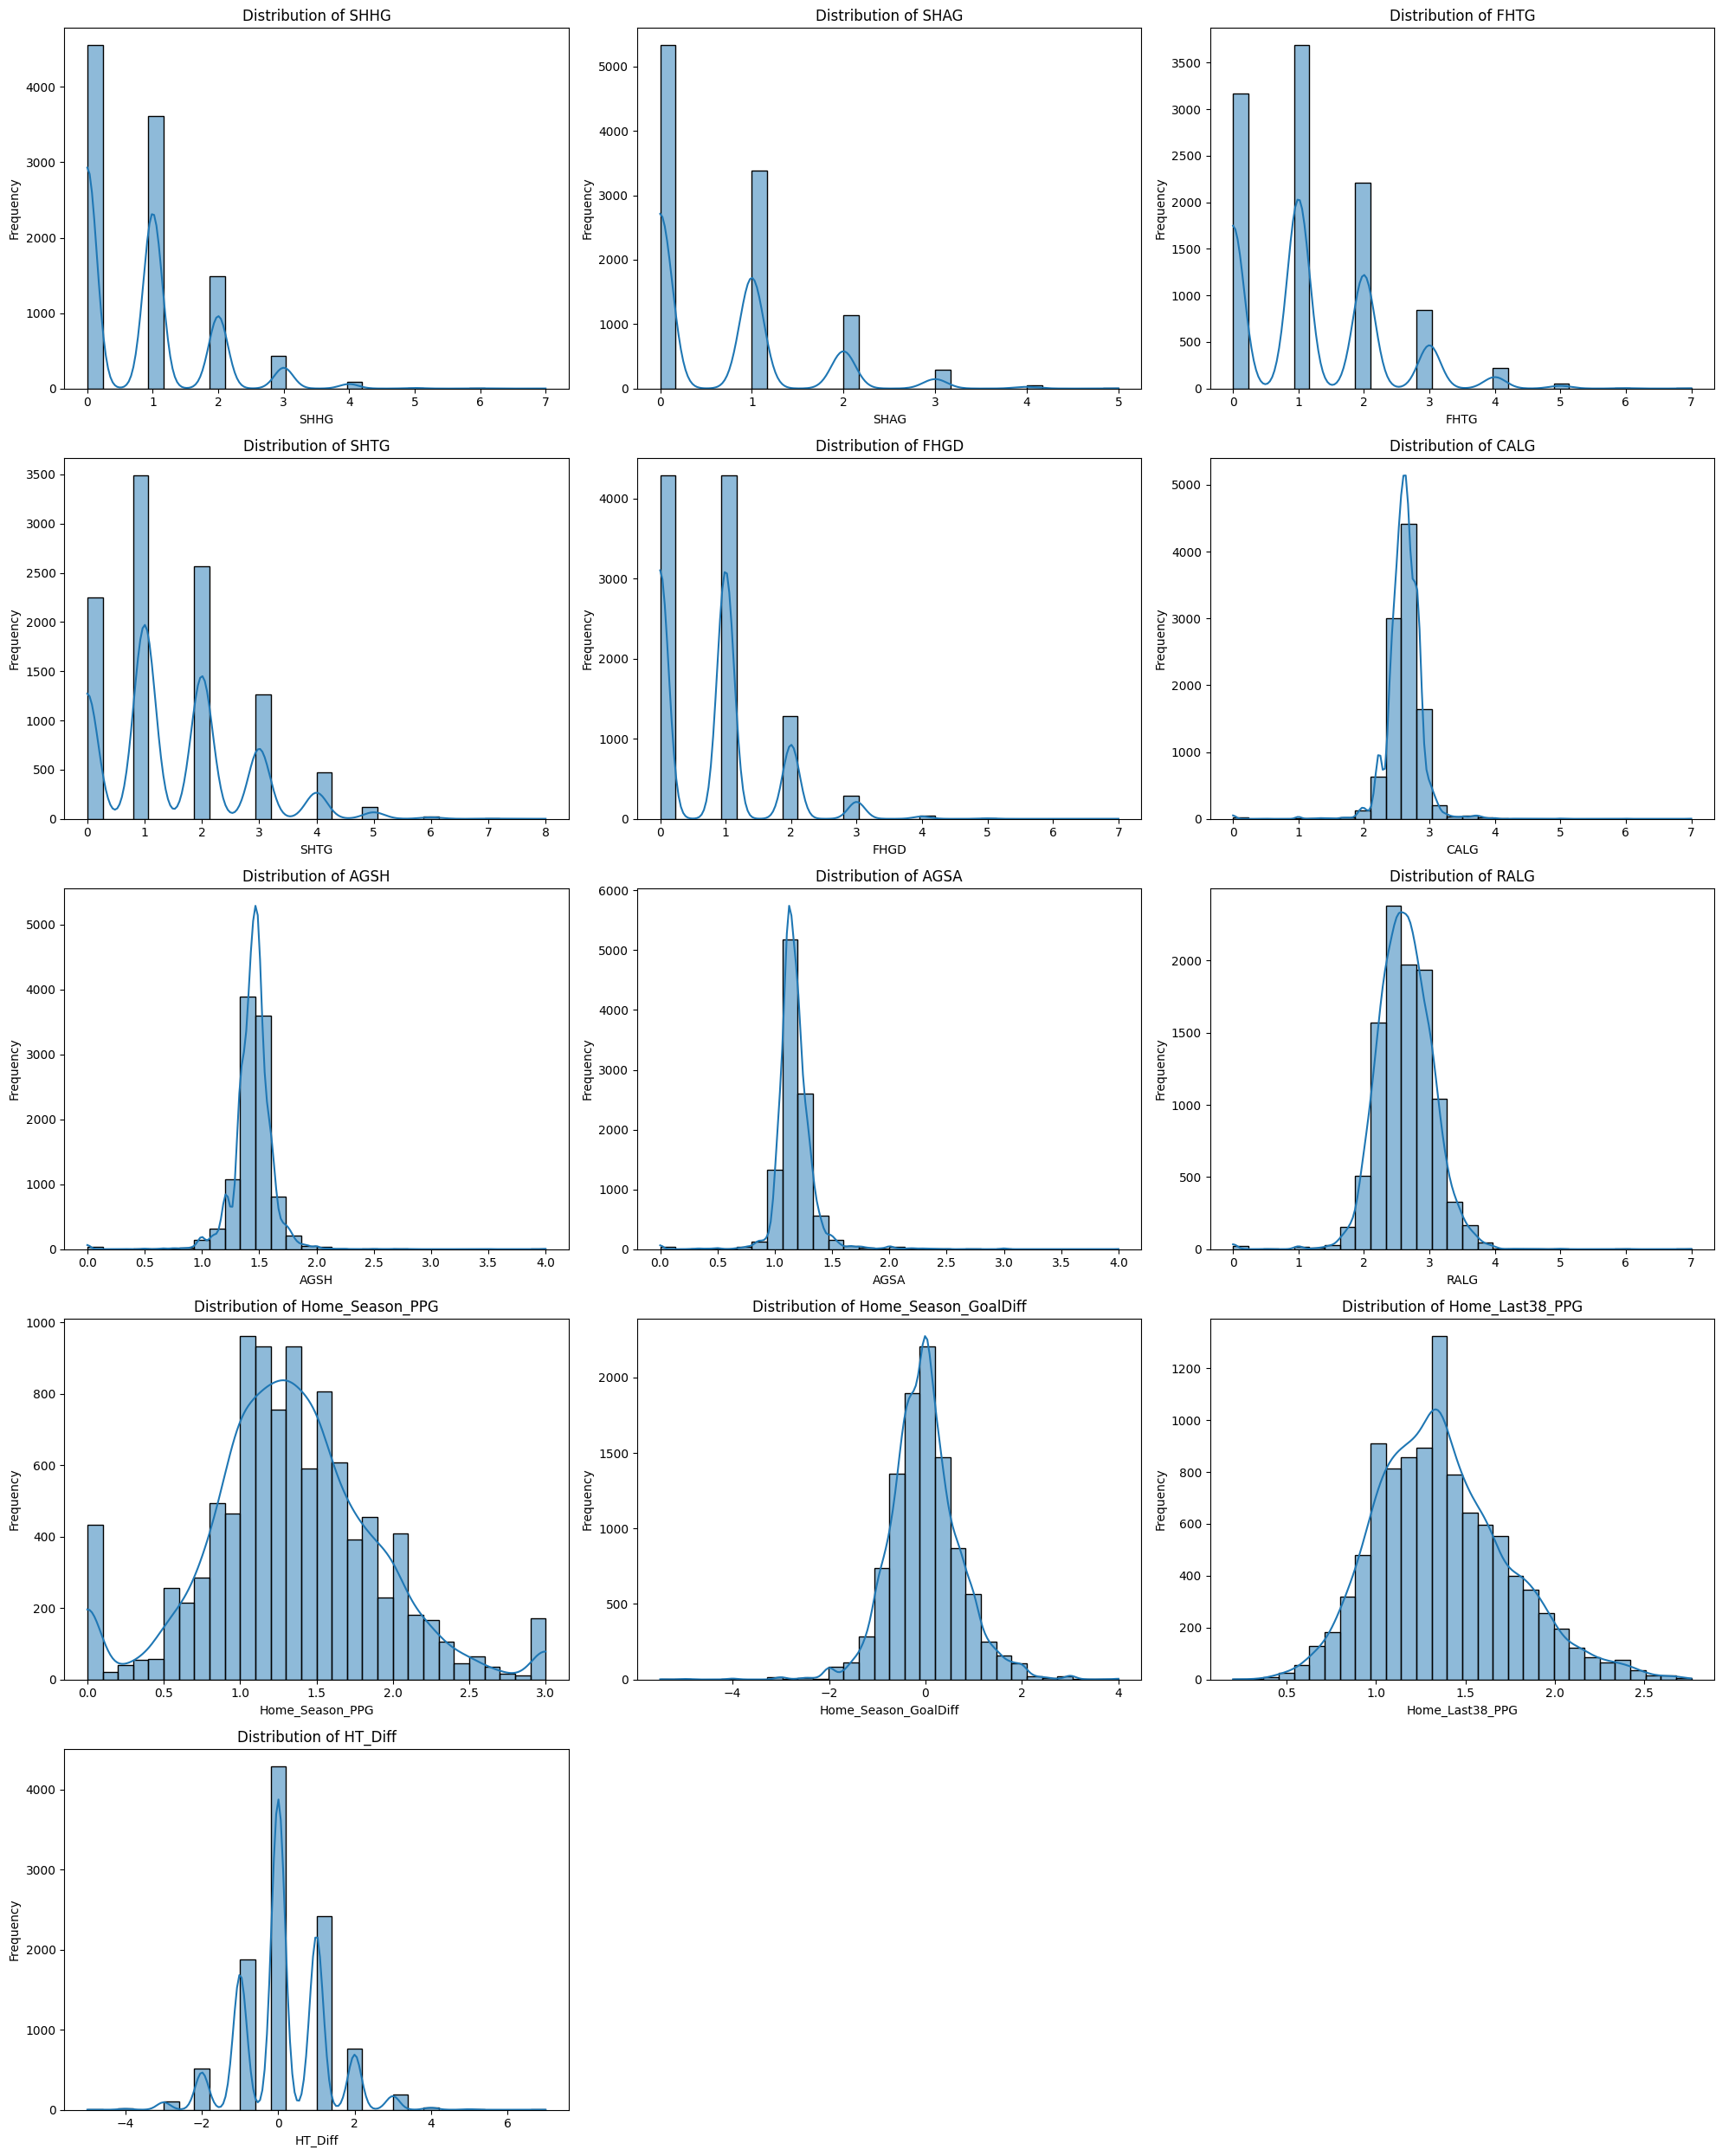

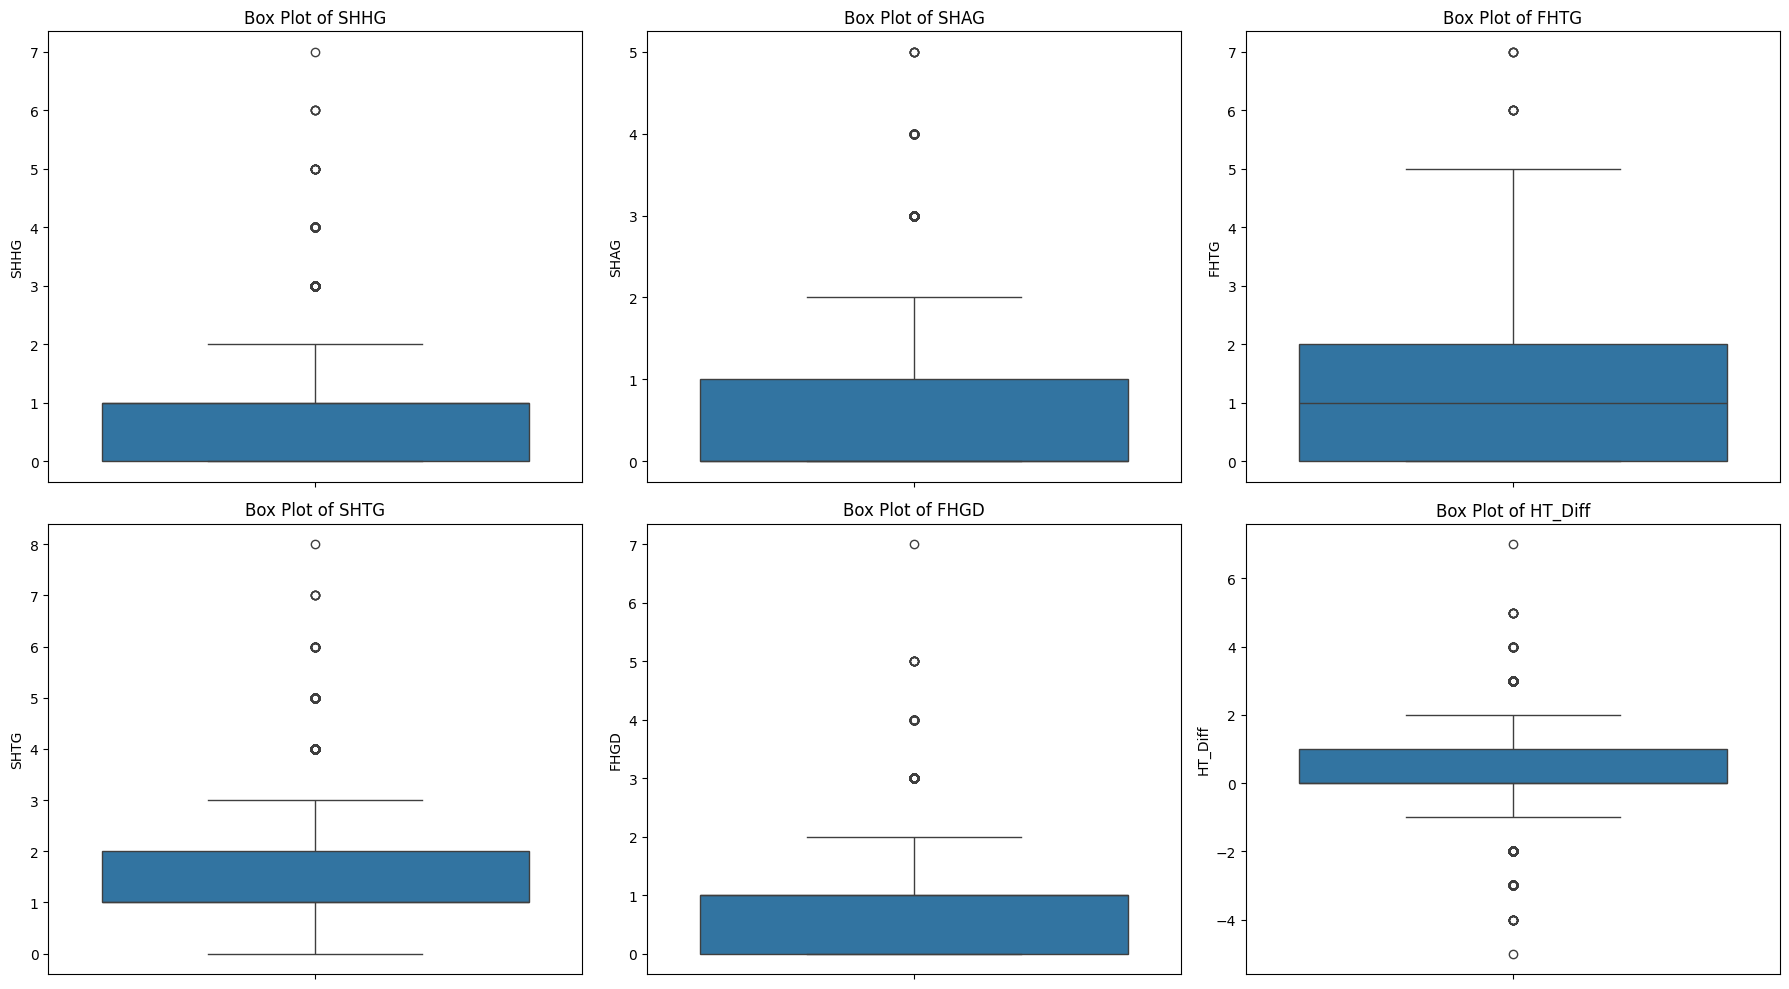

In [ ]:


# Select the relevant newly engineered numerical features
features_to_visualize = [
    'SHHG', 'SHAG', 'FHTG', 'SHTG', 'FHGD', 'CALG', 'AGSH', 'AGSA', 'RALG',
    'Home_Season_PPG', 'Home_Season_GoalDiff', 'Home_Last38_PPG', 'HT_Diff'
]

# Set up the matplotlib figure layout
plt.figure(figsize=(20, 25))

for i, feature in enumerate(features_to_visualize):
    plt.subplot(5, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Optionally, create box plots for features where outliers might be particularly impactful
outlier_features = ['SHHG', 'SHAG', 'FHTG', 'SHTG', 'FHGD', 'HT_Diff']

plt.figure(figsize=(18, 10))

for i, feature in enumerate(outlier_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=data[feature])
    plt.title(f'Box Plot of {feature}')
    plt.xlabel('') # Remove x-label as it's a single column
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

##Est-ce qu'une équipe qui tire beaucoup (HS) a vraiment plus de chances de gagner (FTR)?

/tmp/ipython-input-1564687754.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FTR', y=feature, data=data, order=['H', 'D', 'A'], palette='viridis')
/tmp/ipython-input-1564687754.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FTR', y=feature, data=data, order=['H', 'D', 'A'], palette='viridis')
/tmp/ipython-input-1564687754.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FTR', y=feature, data=data, order=['H', 'D', 'A'], palette='viridis')


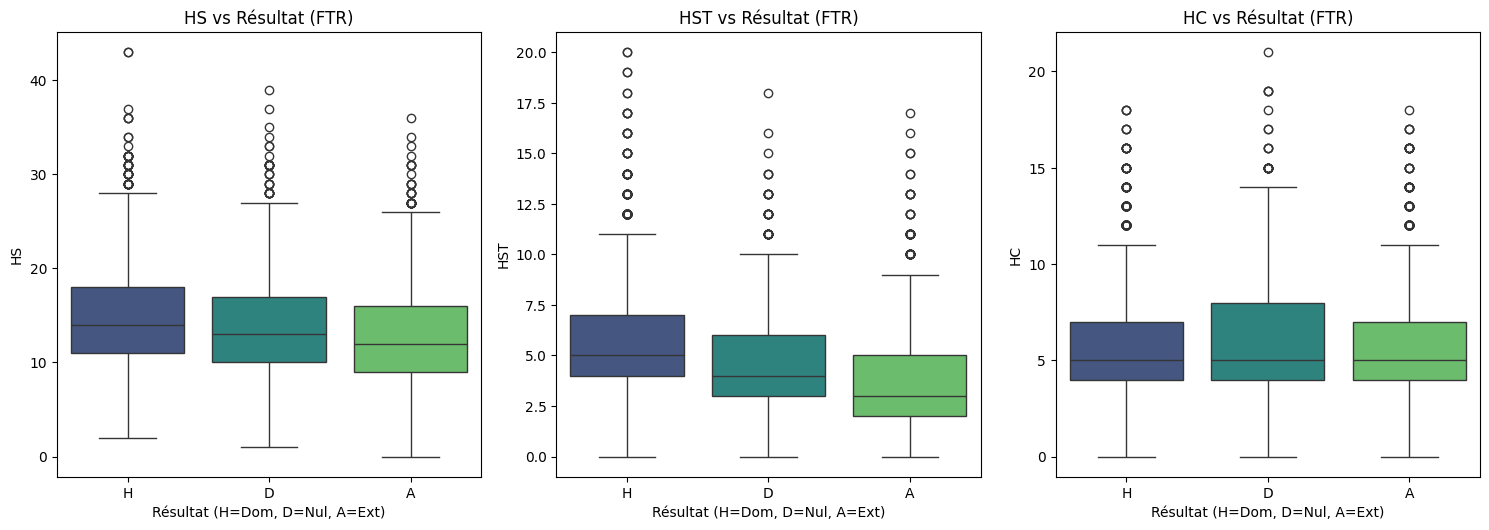

In [36]:


# Liste des features intéressantes à analyser
features_to_plot = ['HS', 'HST', 'HC', 'Home_Rolling_5_Points', 'Home_Cum_GoalDiff']

# On filtre pour ne garder que les features qui existent dans votre df
features_to_plot = [f for f in features_to_plot if f in data.columns]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1) # Grille de graphiques
    # On compare la distribution de la feature selon le résultat du match (H=Home Win, D=Draw, A=Away Win)
    sns.boxplot(x='FTR', y=feature, data=data, order=['H', 'D', 'A'], palette='viridis')
    plt.title(f'{feature} vs Résultat (FTR)')
    plt.xlabel('Résultat (H=Dom, D=Nul, A=Ext)')

plt.tight_layout()
plt.show()

Ainsi cette feature n'aide pas spécialement à désigner les vainqueurs

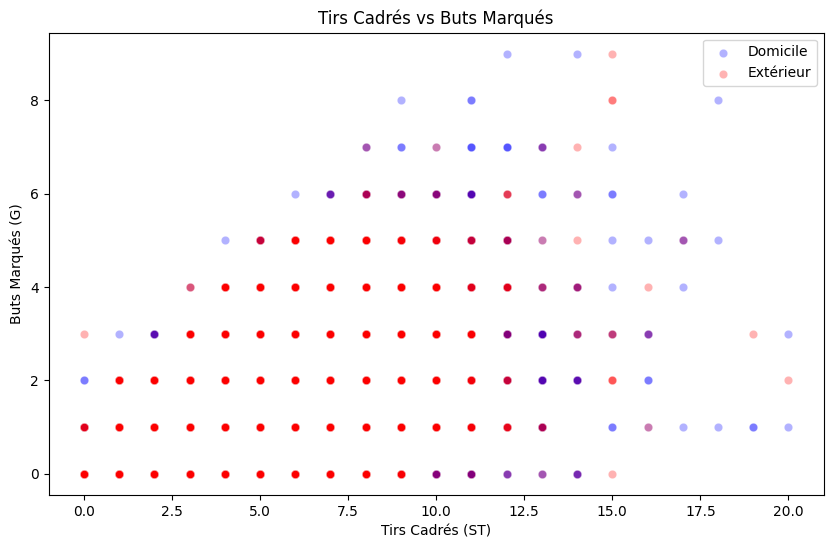

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='HST', y='FTHG', data=data, alpha=0.3, color='blue', label='Domicile')
sns.scatterplot(x='AST', y='FTAG', data=data, alpha=0.3, color='red', label='Extérieur')

plt.title('Tirs Cadrés vs Buts Marqués')
plt.xlabel('Tirs Cadrés (ST)')
plt.ylabel('Buts Marqués (G)')
plt.legend()
plt.show()

Maintenant qu'on a créé des features permettant une indication du niveau de l'équipe et de sa forme on peut créer un modèle que l'on entraîne et évalue sans les features HomeTeam et AwayTeam.

In [20]:
# Définition de la cible (y) et des features (X)
features_to_drop = [
    'id', 'Date', 'Referee', 'Country', 'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG', 'SHHG', 'SHAG', 'SHTG', # features 2nde mi-temps
    'FTTG', 'FTR' # cibles
]


X = data.drop(columns=features_to_drop, errors='ignore')
y1 = data['FTR']
y2 = data['FTTG']

# Identification des types de colonnes
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Caractéristiques numériques ({len(numeric_features)}) : {numeric_features}")
print(f"Caractéristiques catégorielles ({len(categorical_features)}) : {categorical_features}")

# Séparation des données
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=42)
X_train, X_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)
print(f"\nTaille de l'ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} lignes")

Caractéristiques numériques (40) : ['FHHG', 'FHAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'FHTG', 'FHGD', 'RTLM', 'RTLG', 'RTHG', 'RTAG', 'CALG', 'AGSH', 'AGSA', 'RALG', 'RALHG', 'RALAG', 'Home_Season_PPG', 'Home_Season_GoalDiff', 'Home_Last38_PPG', 'Home_Last38_GS', 'Home_Last38_GC', 'Away_Season_PPG', 'Away_Season_GoalDiff', 'Away_Last38_PPG', 'Away_Last38_GS', 'Away_Last38_GC', 'HT_Diff', 'Home_Leading_HT', 'Away_Leading_HT', 'Draw_HT']
Caractéristiques catégorielles (4) : ['League', 'Div', 'Season', 'FHR']

Taille de l'ensemble d'entraînement : 8154 lignes
Taille de l'ensemble de test : 2039 lignes


# Entrainement des modèles

##Entraînement d'un premier modèle

Entraînement du modèle Random Forest en cours...
Entraînement terminé.

Accuracy (Précision globale) : 0.6351 (63.51%)

--- Rapport de Classification ---
              precision    recall  f1-score   support

           A       0.66      0.72      0.68       616
           D       0.46      0.28      0.35       553
           H       0.68      0.81      0.74       870

    accuracy                           0.64      2039
   macro avg       0.60      0.60      0.59      2039
weighted avg       0.61      0.64      0.61      2039



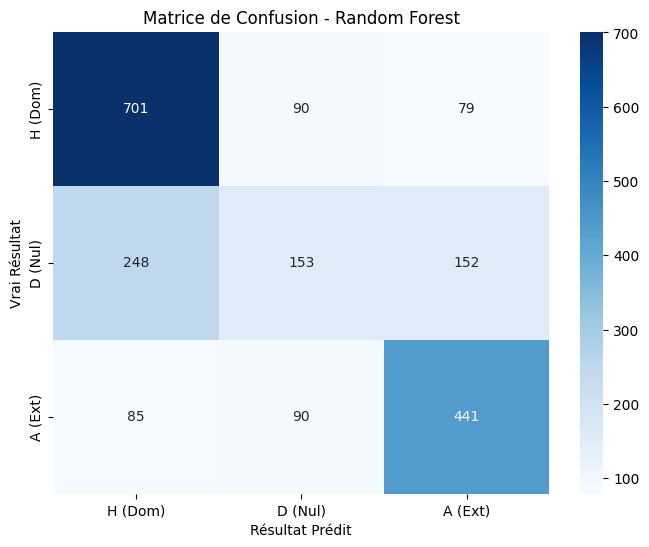

/tmp/ipython-input-2071887821.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')


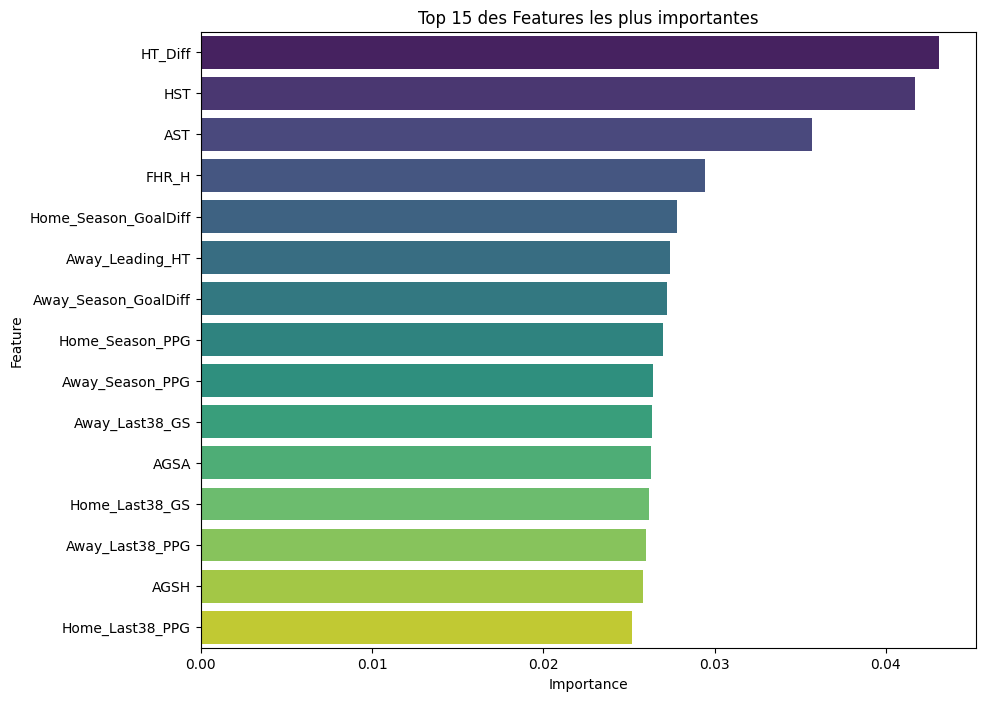

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Preprocessing des données
# Pour les numériques : on remplace les NaN par la médiane et on normalise (StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pour les catégorielles : on remplace les NaN par le plus fréquent et on fait un OneHotEncoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # ignore les nouvelles catégories inconnues au test
])

# On combine les deux dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Création premier modèle : On utilise un Random Forest avec 100 arbres
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Entraînement
print("Entraînement du modèle Random Forest en cours...")
model_rf.fit(X_train, y1_train) # y1 correspond à 'FTR'
print("Entraînement terminé.")

# Prédiction et Évaluation
y_pred = model_rf.predict(X_test)

# Métriques globales
acc = accuracy_score(y1_test, y_pred)
print(f"\nAccuracy (Précision globale) : {acc:.4f} ({acc*100:.2f}%)")

# Rapport détaillé par classe (H, D, A)
print("\n--- Rapport de Classification ---")
print(classification_report(y1_test, y_pred))

# Visualisation de la Matrice de Confusion
# Cela permet de voir où le modèle se trompe (ex: confond-il souvent Nul et Victoire Ext ?)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y1_test, y_pred, labels=['H', 'D', 'A'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['H (Dom)', 'D (Nul)', 'A (Ext)'],
            yticklabels=['H (Dom)', 'D (Nul)', 'A (Ext)'])
plt.title('Matrice de Confusion - Random Forest')
plt.ylabel('Vrai Résultat')
plt.xlabel('Résultat Prédit')
plt.show()

# Importance des Features
# Quelles colonnes ont le plus aidé le modèle ?
# On récupère les noms des features après encodage
feature_names = numeric_features + \
    list(model_rf.named_steps['preprocessor'].named_transformers_['cat']
         .named_steps['encoder'].get_feature_names_out(categorical_features))

importances = model_rf.named_steps['classifier'].feature_importances_

# Création d'un DataFrame pour trier
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15) # Top 15

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Top 15 des Features les plus importantes')
plt.show()

On a déjà une relativement bonne prédiction un modèle aléatoire aurait une accuracy d'environ 0.33. On remarque que globalement le modèle a plus de difficulté à prédire les matchs nul.

##Entrainements et comparaisons

On essaie maintenant d'entraîner différents types de modèle et on les compare.

In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import pandas as pd

# --- 1. Définition des nouveaux modèles ---

# Gradient Boosting (Similaire à XGBoost)
# Souvent meilleur que le Random Forest pour la précision pure
model_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

# Régression Logistique
# Très rapide et interprétable (donne des probabilités bien calibrées)
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42))
])

# SVM (Support Vector Machine)
# Efficace en haute dimension
model_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
])

# Liste des modèles à comparer (On rajoute le RF pour avoir tout sous les yeux si besoin)
models = [
    ("Random Forest", model_rf), # Celui que vous avez déjà entraîné
    ("Gradient Boosting", model_gb),
    ("Logistic Regression", model_lr),
    ("SVM", model_svm)
]

# --- 2. Boucle d'entraînement et d'évaluation ---
results = []

print("Début du comparatif...")

for name, model in models:
    print(f"-> Entraînement de : {name}...")

    # Entraînement
    model.fit(X_train, y1_train)

    # Prédiction
    y_pred_loop = model.predict(X_test)

    # Métriques
    acc = accuracy_score(y1_test, y_pred_loop)

    # On stocke les résultats
    results.append({
        'Modèle': name,
        'Accuracy': acc,
        'Précision (Macro)': classification_report(y1_test, y_pred_loop, output_dict=True)['macro avg']['precision'],
        'Rappel (Macro)': classification_report(y1_test, y_pred_loop, output_dict=True)['macro avg']['recall']
    })

# --- 3. Affichage du Tableau Comparatif ---
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

print("\n--- CLASSEMENT FINAL DES MODÈLES ---")
print(results_df)

# --- 4. Focus sur le meilleur nouveau modèle ---
best_model_name = results_df.iloc[0]['Modèle']
print(f"\nLe meilleur modèle est : {best_model_name}")

# Si le meilleur est le Gradient Boosting, on affiche son rapport détaillé
if best_model_name == "Gradient Boosting":
    print("\n--- Rapport détaillé (Gradient Boosting) ---")
    y_pred_gb = model_gb.predict(X_test)
    print(classification_report(y1_test, y_pred_gb))

Début du comparatif...
-> Entraînement de : Random Forest...
-> Entraînement de : Gradient Boosting...
-> Entraînement de : Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


-> Entraînement de : SVM...

--- CLASSEMENT FINAL DES MODÈLES ---
                Modèle  Accuracy  Précision (Macro)  Rappel (Macro)
2  Logistic Regression  0.639039           0.597876        0.603834
0        Random Forest  0.635115           0.597886        0.599443
3                  SVM  0.633644           0.594067        0.596933
1    Gradient Boosting  0.633154           0.592458        0.597120

Le meilleur modèle est : Logistic Regression


Lancement de la Cross-Validation (10-fold) sur 4 modèles...
-> Traitement de : Random Forest... Fait. (Moyenne: 0.6379)
-> Traitement de : Gradient Boosting... Fait. (Moyenne: 0.6494)
-> Traitement de : Logistic Regression... Fait. (Moyenne: 0.6539)
-> Traitement de : SVM... Fait. (Moyenne: 0.6467)

--- RÉSULTATS CROSS-VALIDATION (10 Folds) ---
                Modèle  Accuracy Moyenne  Écart-Type (Std)       Min       Max
2  Logistic Regression          0.653880          0.016151  0.634936  0.686948
1    Gradient Boosting          0.649368          0.013755  0.631011  0.675172
3                  SVM          0.646718          0.012734  0.630392  0.677134
0        Random Forest          0.637887          0.015175  0.616290  0.664377


/tmp/ipython-input-3671074700.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modèle', y='Accuracy', data=df_details, palette='Set2')


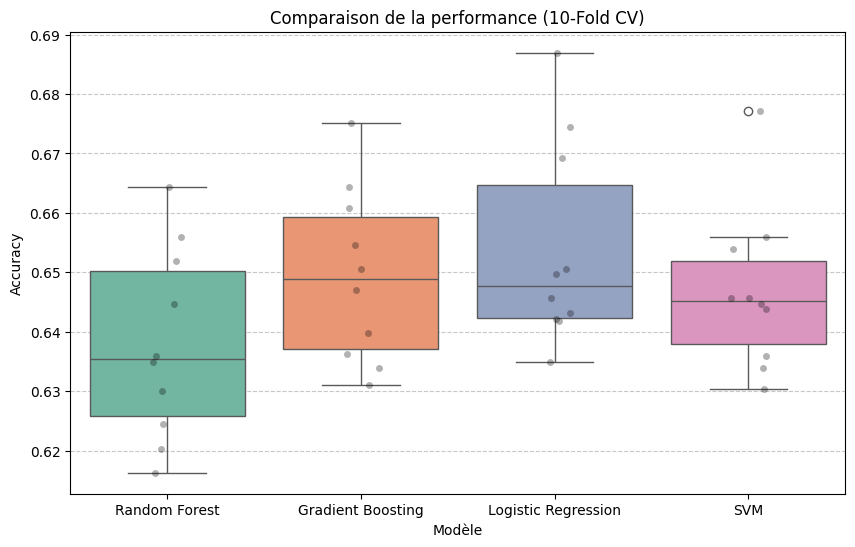

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# --- Configuration de la Cross-Validation ---
# StratifiedKFold assure que chaque "fold" (pli) a la même proportion de H/D/A
# Car match nul souvent moins fréquents
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []
cv_details = [] # Pour le graphique (boxplot)

print(f"Lancement de la Cross-Validation (10-fold) sur {len(models)} modèles...")

for name, model in models:
    print(f"-> Traitement de : {name}...", end=" ")

    # Exécution de la CV
    # On utilise X et y1 (tout le dataset), la CV gère les splits
    # n_jobs=-1 utilise tous les coeurs du processeur pour aller plus vite
    scores = cross_val_score(model, X, y1, cv=cv, scoring='accuracy', n_jobs=-1)

    # Stockage des stats
    cv_results.append({
        'Modèle': name,
        'Accuracy Moyenne': scores.mean(),
        'Écart-Type (Std)': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })

    # Stockage des scores bruts pour le graphique
    for score in scores:
        cv_details.append({'Modèle': name, 'Accuracy': score})

    print(f"Fait. (Moyenne: {scores.mean():.4f})")

# --- Affichage des Résultats ---
df_cv_summary = pd.DataFrame(cv_results).sort_values(by='Accuracy Moyenne', ascending=False)

print("\n--- RÉSULTATS CROSS-VALIDATION (10 Folds) ---")
print(df_cv_summary)

# --- Visualisation (Boxplot) ---
plt.figure(figsize=(10, 6))
df_details = pd.DataFrame(cv_details)

sns.boxplot(x='Modèle', y='Accuracy', data=df_details, palette='Set2')
sns.stripplot(x='Modèle', y='Accuracy', data=df_details, color='black', alpha=0.3) # Montre les points individuels

plt.title('Comparaison de la performance (10-Fold CV)')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [24]:
import pandas as pd
from sklearn.model_selection import cross_val_score

# Récupération des scores détaillés par pli (Fold)
# On utilise un dictionnaire pour stocker les 10 scores de chaque modèle
scores_dict = {}

print("Calcul des scores par fold en cours...")

for name, model in models:
    # On récupère le tableau des 10 scores
    scores = cross_val_score(model, X, y1, cv=cv, scoring='accuracy', n_jobs=-1)
    scores_dict[name] = scores

# Transformation en DataFrame
# Chaque ligne représente un Fold (0 à 9), chaque colonne un modèle
df_scores_detail = pd.DataFrame(scores_dict)

# Détermination du vainqueur pour chaque Fold
# idxmax(axis=1) renvoie le nom de la colonne (Modèle) qui a la valeur max sur la ligne
df_scores_detail['Winner'] = df_scores_detail.idxmax(axis=1)

# Comptage des victoires
win_counts = df_scores_detail['Winner'].value_counts()

# --- Affichage des résultats ---

print("\n--- Compteur de victoires (sur 10 Folds) ---")
print(win_counts)

print("\n--- Détail des duels (Scores par Fold) ---")
# On met en évidence le score max de chaque ligne
def highlight_max(s):
    is_max = s == s.max()
    return ['font-weight: bold; background-color: lightgreen' if v else '' for v in is_max]

# Affichage stylisé (fonctionne dans Jupyter)
try:
    display(df_scores_detail.style.apply(highlight_max, axis=1, subset=df_scores_detail.columns[:-1]))
except:
    # Fallback si 'display' n'existe pas (ex: console standard)
    print(df_scores_detail)

Calcul des scores par fold en cours...


KeyboardInterrupt: 

On voit que le modèle de régression logistique semble bien être le meilleur en effet il est meilleur sur la moitié des folds et a le deuxième meilleur score sur les folds où il n'est pas meilleur à part sur le premier.

Fine Tuning de la régression logistique

In [ ]:
from sklearn.model_selection import GridSearchCV

# Définition de la grille des hyperparamètres à tester
# On teste deux solveurs différents avec leurs pénalités compatibles
param_grid = [
    # Configuration 1 : Solver standard (lbfgs) - ne supporte que L2
    {
        'classifier__solver': ['lbfgs'],
        'classifier__penalty': ['l2'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': [None, 'balanced'] # 'balanced' aide si une classe (ex: Nul) est rare
    },
    # Configuration 2 : Solver avancé (saga) - supporte L1 et L2
    {
        'classifier__solver': ['saga'],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': [None, 'balanced']
    }
]

# Configuration de la recherche (Grid Search)
# cv=5 : On fait une validation croisée à 5 plis pour chaque combinaison
grid_search = GridSearchCV(
    model_lr, # Votre pipeline existant
    param_grid,
    cv=5,
    scoring='accuracy', # On optimise l'Accuracy
    n_jobs=-1, # Utilise tous les coeurs du CPU
    verbose=1
)

print("Recherche des meilleurs hyperparamètres en cours...")
grid_search.fit(X_train, y1_train)

# --- Résultats ---
print(f"\nMeilleurs paramètres trouvés :")
print(grid_search.best_params_)

print(f"\nMeilleure Accuracy (Validation Croisée) : {grid_search.best_score_:.4f}")

# --- Évaluation finale sur le Test Set (qui n'a pas servi à l'optimisation) ---
best_model = grid_search.best_estimator_
final_acc = best_model.score(X_test, y1_test)

print(f"Accuracy Finale sur le Test Set : {final_acc:.4f}")

# Comparaison rapide avec le modèle par défaut
base_acc = model_lr.score(X_test, y1_test) if hasattr(model_lr, 'score') else 0
print(f"Gain par rapport au modèle par défaut : {(final_acc - base_acc)*100:.2f} points")

Maintenant on veut fintuner notre modèle

1. Optimisation du Gradient Boosting Classifier

In [ ]:
from sklearn.model_selection import GridSearchCV

# Définition du Pipeline
model_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Grille d'hyperparamètres

param_grid_gb = {
    'classifier__n_estimators': [100, 200, 300],  # Nombre d'arbres
    'classifier__learning_rate': [0.01, 0.1, 0.2], # Vitesse
    'classifier__max_depth': [3, 5]

}

print("Optimisation Gradient Boosting...")
grid_gb = GridSearchCV(model_gb, param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train, y1_train)

print(f"Meilleurs paramètres GB : {grid_gb.best_params_}")
print(f"Meilleure Accuracy GB : {grid_gb.best_score_:.4f}")

Optimisation du SVM (Support Vector Machine)

In [ ]:


#Définition du Pipeline
# Ajout de class_weight='balanced' pour aider sur les matchs nuls
model_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, class_weight='balanced', random_state=42))
])

#Distributions d'hyperparamètres (Plus intelligentes)
param_dist_svm = {
    # C : On cherche sur une échelle logarithmique de 0.1 à 1000

    'classifier__C': loguniform(0.1, 1000),

    # Kernel : On garde les deux principaux
    'classifier__kernel': ['linear', 'rbf'],


    'classifier__gamma': loguniform(0.0001, 1.0),

    # On peut aussi tester le degré pour le kernel 'poly' si on voulait
    # 'classifier__degree': [2, 3, 4]
}

print("Optimisation SVM Avancée (Randomized Search)...")

# On teste 50 combinaisons au hasard dans ces grands espaces
random_search_svm = RandomizedSearchCV(
    model_svm,
    param_distributions=param_dist_svm,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_svm.fit(X_train, y1_train)

print(f"Meilleurs paramètres SVM : {random_search_svm.best_params_}")
print(f"Meilleure Accuracy SVM : {random_search_svm.best_score_:.4f}")

# Récupération du champion
best_svm_model = random_search_svm.best_estimator_